In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.inspection import permutation_importance

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [12]:
# Data Collection
# --- 1. DATA COLLECTION ---
# Import data from csv file
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')
# df


In [13]:
# --- 2. PRE-PROCESSING & FEATURE ENGINEERING ---
filtered = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered['Home_Score'] > filtered['Away_Score']),
    (filtered['Away_Score'] > filtered['Home_Score']),
    (filtered['Home_Score'] == filtered['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
match_outcome_dict = dict(zip(filtered['Game_ID'], filtered['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(match_outcome_dict)

df_filtered = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_filtered['Time'] = df_filtered['Time'].apply(eval) 

# Feature Engineering to minimize score dominance
df_filtered['Score_Diff'] = df_filtered['Home_Score'] - df_filtered['Away_Score']
df_filtered['Total_Goals'] = df_filtered['Home_Score'] + df_filtered['Away_Score']
df_filtered['Home_Score_Log'] = np.log1p(df_filtered['Home_Score'])
df_filtered['Away_Score_Log'] = np.log1p(df_filtered['Away_Score'])

EDA

In [14]:
# df_filtered.describe()
df_filtered.describe(include=['object'])

,Game_ID,Matchweek,Game_Type,Team,Match_URL,Event_Type,Player_1,Pos_1,Player_2,Pos_2,Note,Match_Outcomes
count,106598,106598,106598,106598,106598,106598,106598,106598,78813,78813,106598,106598
unique,6310,38,1,2,7155,4,3997,14,4634,15,6,3
top,120230701,4,League,Home,https://fbref.com/en/matches/bc7df752/Bayern-M...,Substitution,Vincenzo Grifo,FW,Kevin Behrens,FW,Neutral Sub,Home_Win
freq,99,3054,106598,54573,42,78813,266,25033,131,16109,60365,48171


Train/Test Split

C:\Users\matth\AppData\Local\Temp\ipykernel_13164\4190201726.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


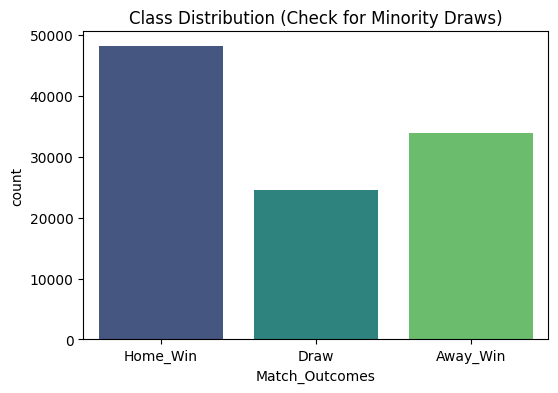

In [15]:
# --- 3. TRAIN/TEST SPLIT ---
X = df_filtered[['Time', 'Score_Diff', 'Total_Goals', 'Home_Score_Log', 'Away_Score_Log', 
                'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 
                'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']]
y = df_filtered['Match_Outcomes']

# Visualizing Class Imbalance before training
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title("Class Distribution (Check for Minority Draws)")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

Randomized Search - Find best k value

In [16]:
# --- 4. PIPELINE WITH CLASS WEIGHT CONSIDERATIONS ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

param_distributions = {
    'pca__n_components': range(1, X.shape[1] + 1),
    'knn__n_neighbors': range(1, 51),
    # 'distance' weight helps with class imbalance by rewarding closer, specific matches
    'knn__weights': ['uniform', 'distance'], 
    'knn__metric': ['euclidean', 'manhattan']
}

# Use 'f1_weighted' instead of 'accuracy' to penalize poor performance on minority classes (Draws)
cv_strategy = StratifiedKFold(n_splits=5)
random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_distributions, n_iter=30, 
    cv=cv_strategy, scoring='f1_weighted', random_state=42, refit=True
)
random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Training F1-Weighted Score: {random_search.best_score_:.4f}")

Best Parameters: {'pca__n_components': 4, 'knn__weights': 'distance', 'knn__n_neighbors': 28, 'knn__metric': 'manhattan'}
Best Training F1-Weighted Score: 0.6805



Final Classification Report:
              precision    recall  f1-score   support

    Away_Win       0.67      0.73      0.70      6779
        Draw       0.55      0.46      0.50      4907
    Home_Win       0.75      0.77      0.76      9634

    accuracy                           0.69     21320
   macro avg       0.66      0.65      0.65     21320
weighted avg       0.68      0.69      0.68     21320



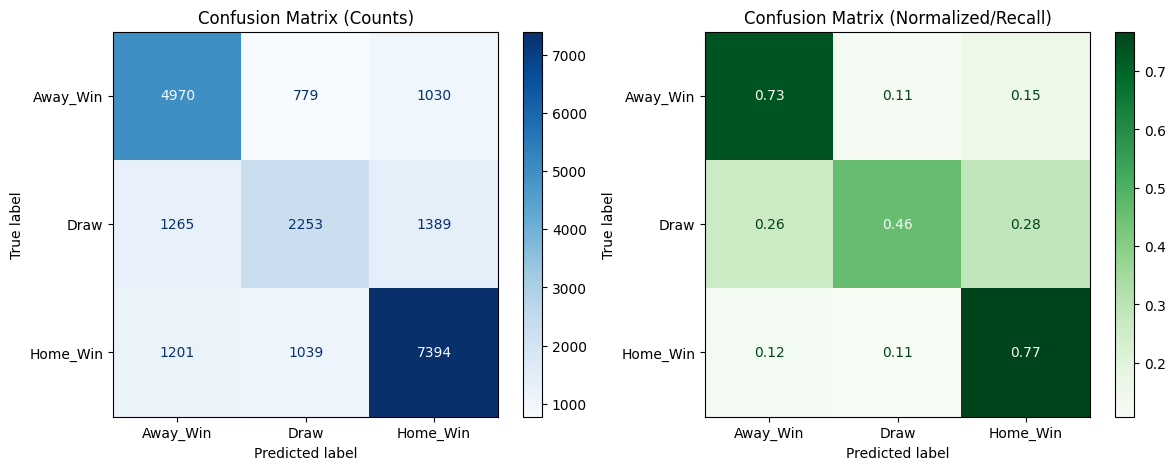

In [17]:
# --- 5. EVALUATION ---
y_pred = random_search.predict(X_test)
target_names = sorted(y.unique())

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix (Normalized to see percentage accuracy per class)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, 
                                        cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion Matrix (Counts)")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, 
                                        cmap="Greens", normalize='true', ax=ax[1])
ax[1].set_title("Confusion Matrix (Normalized/Recall)")
plt.show()

C:\Users\matth\AppData\Local\Temp\ipykernel_13164\4076063116.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance_mean', y='feature', palette='magma')


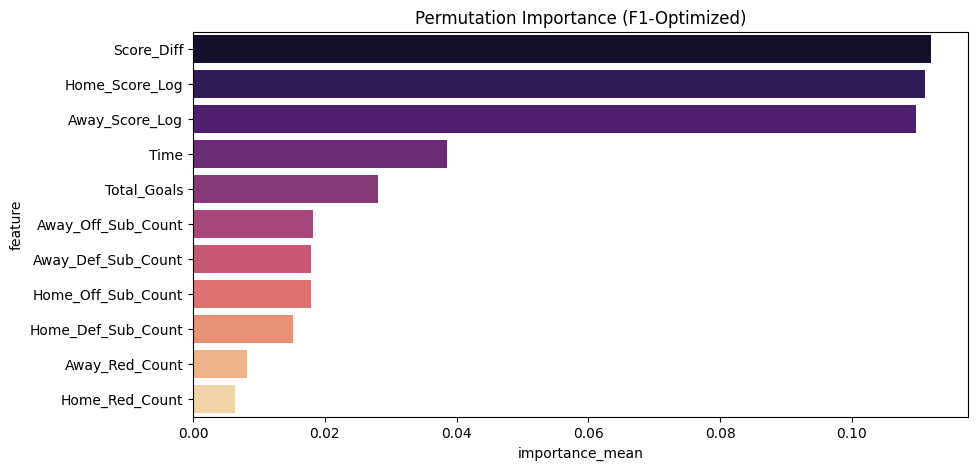

In [18]:
# --- 6. FEATURE ANALYSIS ---
result = permutation_importance(random_search, X_test, y_test, n_repeats=10, random_state=42)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x='importance_mean', y='feature', palette='magma')
plt.title("Permutation Importance (F1-Optimized)")
plt.show()

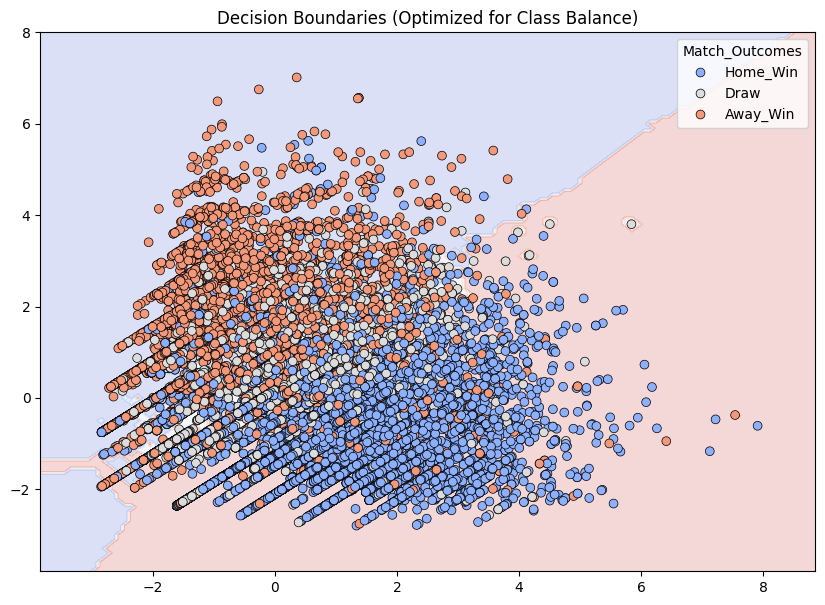

In [19]:
# --- 7. VISUALIZATION: 2D PCA DECISION BOUNDARIES ---
best_pca = random_search.best_estimator_.named_steps['pca']
scaler = random_search.best_estimator_.named_steps['scaler']

X_scaled_test = scaler.transform(X_test)
X_pca_2d = best_pca.transform(X_scaled_test)[:, :2]

h = .1
x_min, x_max = X_pca_2d[:, 0].min() - 1, X_pca_2d[:, 0].max() + 1
y_min, y_max = X_pca_2d[:, 1].min() - 1, X_pca_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

viz_knn = KNeighborsClassifier(n_neighbors=random_search.best_params_['knn__n_neighbors'], 
                               weights=random_search.best_params_['knn__weights'])
viz_knn.fit(X_pca_2d, y_test)
Z = viz_knn.predict(np.c_[xx.ravel(), yy.ravel()])

label_to_int = {lab: i for i, lab in enumerate(viz_knn.classes_)}
Z_int = np.array([label_to_int[val] for val in Z]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_int, alpha=0.2, cmap='coolwarm')
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y_test, 
                palette='coolwarm', edgecolor='k', s=40)
plt.title("Decision Boundaries (Optimized for Class Balance)")
plt.show()